In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

In [2]:
df = pd.read_csv("../data/cleaned_telco.csv")
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
model = joblib.load("../models/churn_model.joblib")

C:\Users\Harsh\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Harsh\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Harsh\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.2 when using version 1.6.1. This might lead to breaking code o

In [5]:
df.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [6]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols='deprecated',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  ['Gender', 'Tenure Months',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Monthly Charges',
                                                   'Total Charg...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [7]:
model.named_steps

{'preprocessor': ColumnTransformer(force_int_remainder_cols='deprecated',
                   transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('Scaler', StandardScaler())]),
                                  ['Gender', 'Tenure Months', 'Online Security',
                                   'Online Backup', 'Device Protection',
                                   'Tech Support', 'Streaming TV',
                                   'Streaming Movies', 'Monthly Charges',
                                   'Total Charges', 'Charge_to_Tenure',
                                   'Service_Count']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                      

In [8]:
# convert gender
df["Gender"] = df["Gender"].map({"Male":1, "Female":0})

# convert yes/no service columns
yes_no_cols = [
"Online Security",
"Online Backup",
"Device Protection",
"Tech Support",
"Streaming TV",
"Streaming Movies"
]

for col in yes_no_cols:
    df[col] = df[col].map({"Yes":1, "No":0})

# recreate engineered features (important)
df["Charge_to_Tenure"] = df["Total Charges"] / (df["Tenure Months"] + 1)

services = [
"Online Security",
"Online Backup",
"Device Protection",
"Tech Support",
"Streaming TV",
"Streaming Movies"
]

df["Service_Count"] = df[services].sum(axis=1)

df["Tenure_Group"] = pd.cut(
    df["Tenure Months"],
    bins=[0,12,24,48,72],
    labels=["0-1yr","1-2yr","2-4yr","4-6yr"]
)

In [11]:
features = [
'Gender','Tenure Months','Online Security','Online Backup',
'Device Protection','Tech Support','Streaming TV','Streaming Movies',
'Monthly Charges','Total Charges','Charge_to_Tenure','Service_Count',
'Senior Citizen','Partner','Dependents','Phone Service','Multiple Lines',
'Internet Service','Contract','Paperless Billing','Payment Method','Tenure_Group'
]
df = df.rename(columns={"Churn Value": "Churn"})
X = df[features]
y = df["Churn"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [14]:
print(X_test.dtypes)

Gender                  int64
Tenure Months           int64
Online Security       float64
Online Backup         float64
Device Protection     float64
Tech Support          float64
Streaming TV          float64
Streaming Movies      float64
Monthly Charges       float64
Total Charges         float64
Charge_to_Tenure      float64
Service_Count         float64
Senior Citizen         object
Partner                object
Dependents             object
Phone Service          object
Multiple Lines         object
Internet Service       object
Contract               object
Paperless Billing      object
Payment Method         object
Tenure_Group         category
dtype: object


In [16]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[707 305]
 [ 63 332]]


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1012
           1       0.52      0.84      0.64       395

    accuracy                           0.74      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.74      0.75      1407



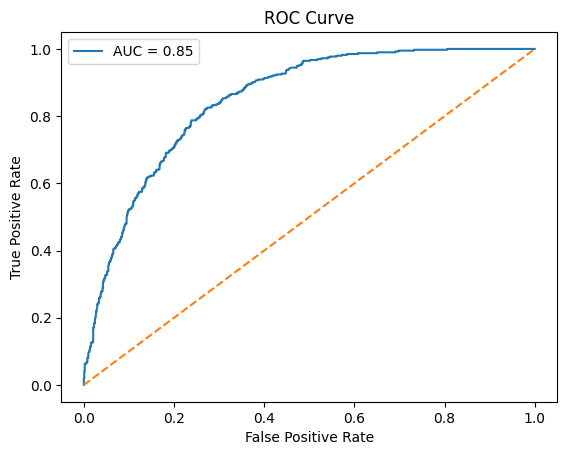

In [18]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()